Loading data...
Data Cleaning Finished!


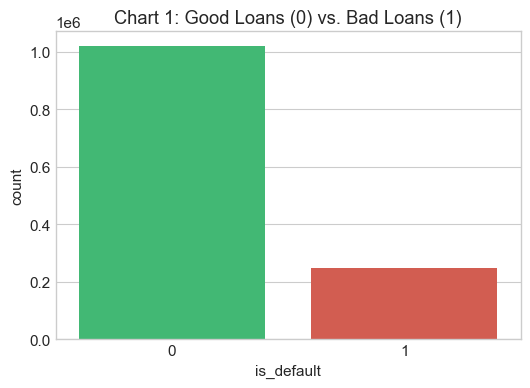

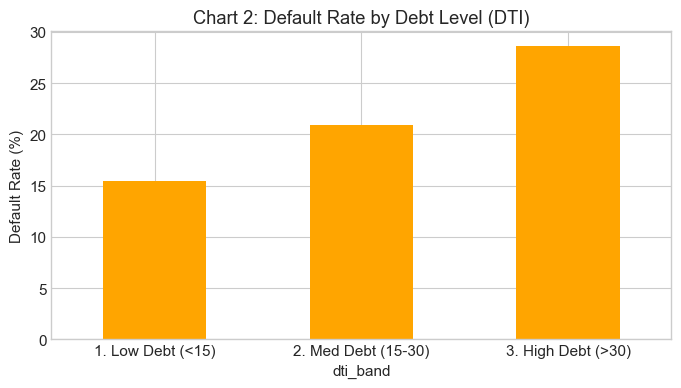

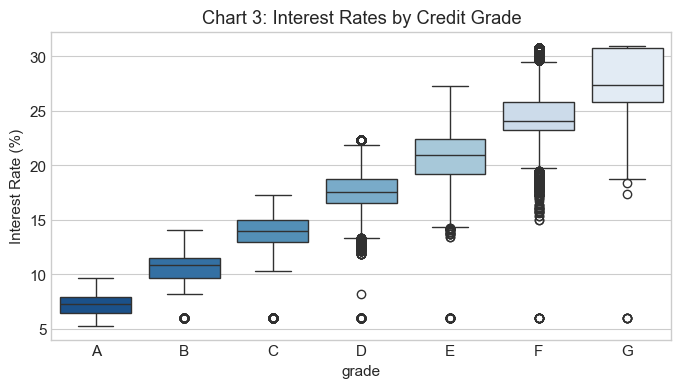

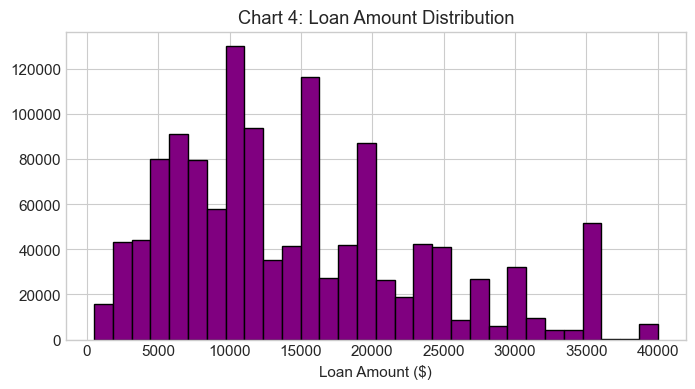

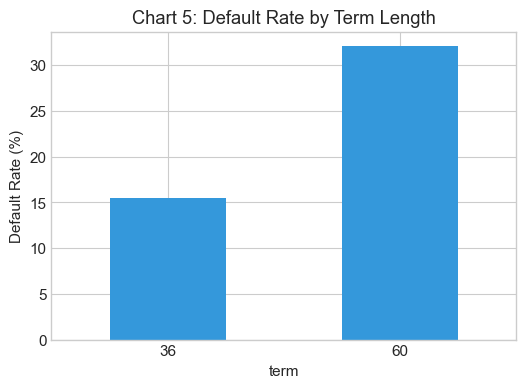

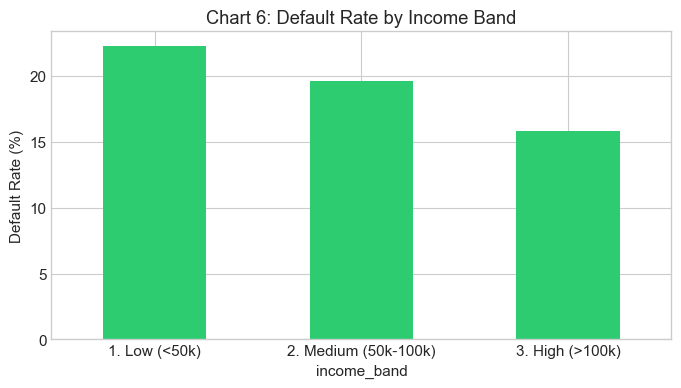

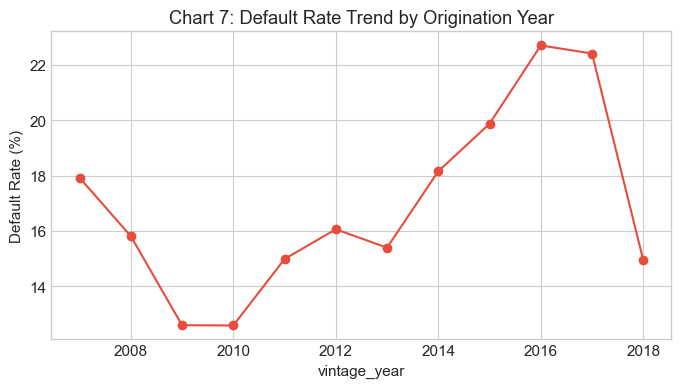

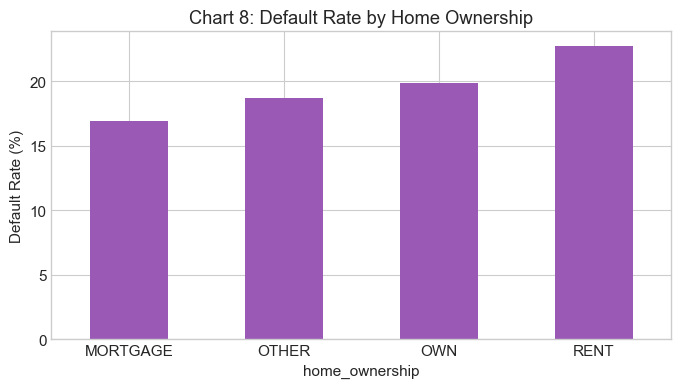

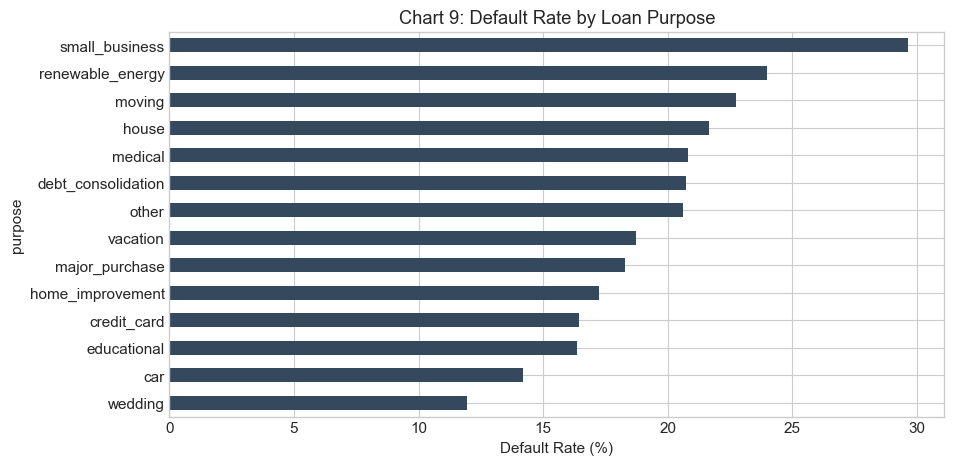

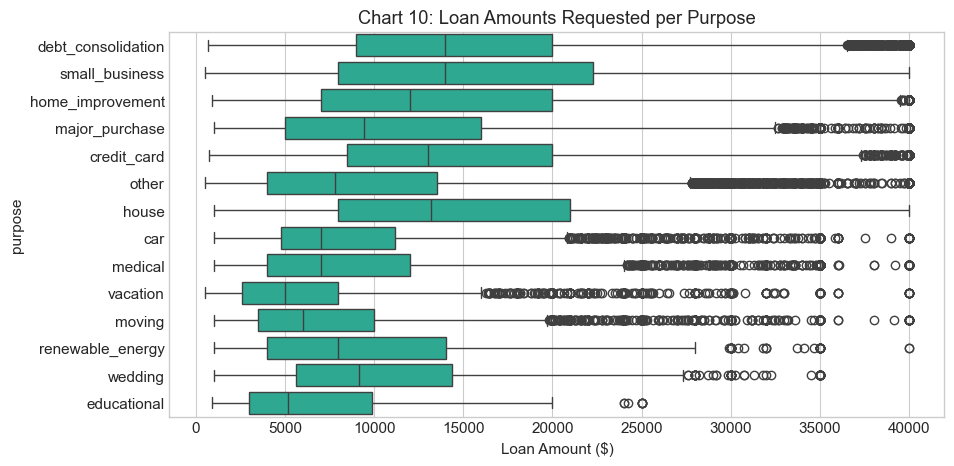

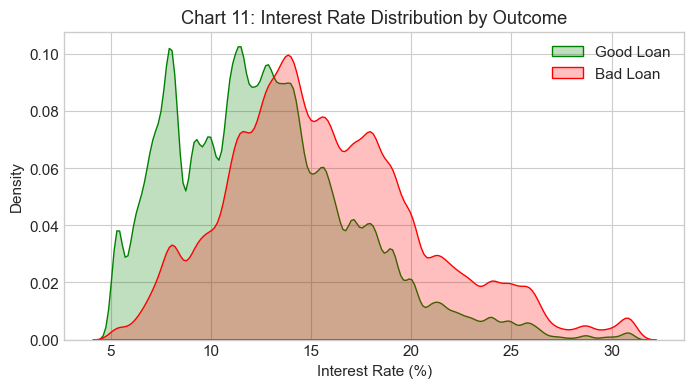

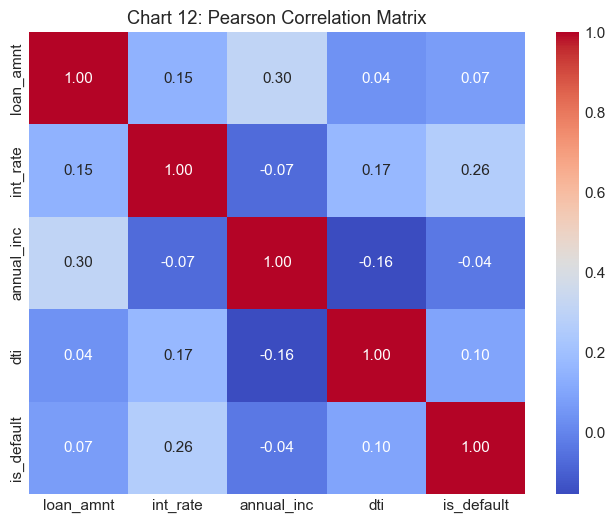


--- STATISTICAL TEST ---
Hypothesis: Do 60-month loans have a higher average interest rate than 36-month loans?
Average Interest Rate (36 months): 12.08%
Average Interest Rate (60 months): 16.76%
T-Statistic: 487.24
P-Value: 0.00000
Conclusion: The difference is statistically significant. 60-month loans are charged significantly higher rates.

File successfully saved to: C:/Users/NGC/cleaned_lending_club_data.csv


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats  # Added for the statistical test

# Make the charts look nice
plt.style.use('seaborn-v0_8-whitegrid')

# ==========================================
# STEP 1: Load the Data
# ==========================================
print("Loading data...")
file_path = "C:/Users/NGC/accepted_2007_to_2018Q4.csv"
df_raw = pd.read_csv(file_path, low_memory=False)

# ==========================================
# STEP 2: Keep Only Finished Loans & Map Outcomes
# ==========================================
df_finished = df_raw[(df_raw['loan_status'] == 'Fully Paid') | (df_raw['loan_status'] == 'Charged Off')].copy()

def flag_bad_loan(status):
    if status == 'Charged Off':
        return 1  
    else:
        return 0  

df_finished['is_default'] = df_finished['loan_status'].apply(flag_bad_loan)

# ==========================================
# STEP 3: Prevent Target Leakage
# ==========================================
# Added 'purpose' and 'home_ownership' as required by the project
columns_we_need = [
    'loan_amnt', 'term', 'int_rate', 'grade', 
    'annual_inc', 'dti', 'issue_d', 'emp_length', 
    'purpose', 'home_ownership', 'is_default'
]
df = df_finished[columns_we_need].copy()
df = df.dropna()

# ==========================================
# STEP 4: Simple Data Cleaning
# ==========================================
df['int_rate'] = df['int_rate'].astype(str).str.replace('%', '').astype(float)
df['term'] = df['term'].astype(str).str.replace(' months', '').astype(int)
df['issue_d'] = pd.to_datetime(df['issue_d'], format='%b-%Y')
df['vintage_year'] = df['issue_d'].dt.year

def clean_employment(emp_text):
    emp_text = str(emp_text)
    if '< 1' in emp_text: return 0
    if '10+' in emp_text: return 10
    if '1' in emp_text: return 1
    if '2' in emp_text: return 2
    if '3' in emp_text: return 3
    if '4' in emp_text: return 4
    if '5' in emp_text: return 5
    if '6' in emp_text: return 6
    if '7' in emp_text: return 7
    if '8' in emp_text: return 8
    if '9' in emp_text: return 9
    return 0 

df['emp_length_years'] = df['emp_length'].apply(clean_employment)

def categorize_income(income):
    if income < 50000: return '1. Low (<50k)'
    elif income < 100000: return '2. Medium (50k-100k)'
    else: return '3. High (>100k)'

df['income_band'] = df['annual_inc'].apply(categorize_income)

def categorize_dti(dti):
    if dti < 15: return '1. Low Debt (<15)'
    elif dti < 30: return '2. Med Debt (15-30)'
    else: return '3. High Debt (>30)'

df['dti_band'] = df['dti'].apply(categorize_dti)

# Clean Home Ownership (Group small categories together)
def clean_home(home):
    if home in ['MORTGAGE', 'RENT', 'OWN']:
        return home
    return 'OTHER'
df['home_ownership'] = df['home_ownership'].apply(clean_home)

print("Data Cleaning Finished!")

# ==========================================
# STEP 5: Exploratory Data Analysis (12 Charts)
# ==========================================
# Chart 1: Target Variable
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='is_default', hue='is_default', palette=['#2ecc71', '#e74c3c'], legend=False)
plt.title('Chart 1: Good Loans (0) vs. Bad Loans (1)')
plt.show()

# Chart 2: Default Rate by Debt Level
plt.figure(figsize=(8, 4))
df.groupby('dti_band')['is_default'].mean().mul(100).plot(kind='bar', color='orange')
plt.title('Chart 2: Default Rate by Debt Level (DTI)')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=0)
plt.show()

# Chart 3: Interest Rates by Credit Grade
plt.figure(figsize=(8, 4))
sns.boxplot(data=df.sort_values('grade'), x='grade', y='int_rate', hue='grade', palette='Blues_r', legend=False)
plt.title('Chart 3: Interest Rates by Credit Grade')
plt.ylabel('Interest Rate (%)')
plt.show()

# Chart 4: Distribution of Loan Amounts
plt.figure(figsize=(8, 4))
plt.hist(df['loan_amnt'], bins=30, color='purple', edgecolor='black')
plt.title('Chart 4: Loan Amount Distribution')
plt.xlabel('Loan Amount ($)')
plt.show()

# Chart 5: Default Rate by Loan Term
plt.figure(figsize=(6, 4))
df.groupby('term')['is_default'].mean().mul(100).plot(kind='bar', color='#3498db')
plt.title('Chart 5: Default Rate by Term Length')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=0)
plt.show()

# Chart 6: Default Rate by Income Band
plt.figure(figsize=(8, 4))
df.groupby('income_band')['is_default'].mean().mul(100).plot(kind='bar', color='#2ecc71')
plt.title('Chart 6: Default Rate by Income Band')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=0)
plt.show()

# Chart 7: Default Rate Trend Over Years
plt.figure(figsize=(8, 4))
df.groupby('vintage_year')['is_default'].mean().mul(100).plot(kind='line', marker='o', color='#e74c3c')
plt.title('Chart 7: Default Rate Trend by Origination Year')
plt.ylabel('Default Rate (%)')
plt.show()

# NEW Chart 8: Default Rate by Home Ownership
plt.figure(figsize=(8, 4))
df.groupby('home_ownership')['is_default'].mean().mul(100).plot(kind='bar', color='#9b59b6')
plt.title('Chart 8: Default Rate by Home Ownership')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=0)
plt.show()

# NEW Chart 9: Default Rate by Loan Purpose
plt.figure(figsize=(10, 5))
purpose_summary = df.groupby('purpose')['is_default'].mean().mul(100).sort_values()
purpose_summary.plot(kind='barh', color='#34495e')
plt.title('Chart 9: Default Rate by Loan Purpose')
plt.xlabel('Default Rate (%)')
plt.show()

# NEW Chart 10: Loan Amount by Loan Purpose
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='loan_amnt', y='purpose', color='#1abc9c')
plt.title('Chart 10: Loan Amounts Requested per Purpose')
plt.xlabel('Loan Amount ($)')
plt.show()

# NEW Chart 11: Interest Rate Distribution (Good vs Bad Loans)
plt.figure(figsize=(8, 4))
sns.kdeplot(data=df[df['is_default']==0], x='int_rate', label='Good Loan', color='green', fill=True)
sns.kdeplot(data=df[df['is_default']==1], x='int_rate', label='Bad Loan', color='red', fill=True)
plt.title('Chart 11: Interest Rate Distribution by Outcome')
plt.xlabel('Interest Rate (%)')
plt.legend()
plt.show()

# NEW Chart 12: Correlation Heatmap (Multivariate)
plt.figure(figsize=(8, 6))
numeric_cols = ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'is_default']
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Chart 12: Pearson Correlation Matrix')
plt.show()

# ==========================================
# STEP 6: Required Statistical Comparison
# ==========================================
# Requirement: "One statistical comparison, with assumptions and effect size or confidence interval"
print("\n--- STATISTICAL TEST ---")
print("Hypothesis: Do 60-month loans have a higher average interest rate than 36-month loans?")

# Separate the interest rates by term length
rates_36 = df[df['term'] == 36]['int_rate']
rates_60 = df[df['term'] == 60]['int_rate']

# Run an Independent T-Test
t_stat, p_value = stats.ttest_ind(rates_60, rates_36, equal_var=False)

print(f"Average Interest Rate (36 months): {rates_36.mean():.2f}%")
print(f"Average Interest Rate (60 months): {rates_60.mean():.2f}%")
print(f"T-Statistic: {t_stat:.2f}")
print(f"P-Value: {p_value:.5f}")

if p_value < 0.05:
    print("Conclusion: The difference is statistically significant. 60-month loans are charged significantly higher rates.")
else:
    print("Conclusion: The difference is NOT statistically significant.")

# ==========================================
# STEP 7: Export for Power BI
# ==========================================
output_path = "C:/Users/NGC/cleaned_lending_club_data.csv"
df.to_csv(output_path, index=False)
print(f"\nFile successfully saved to: {output_path}")